# 데이터 불러오기 + 관찰

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bike = pd.read_csv('/서울특별시 공공자전거 이용정보(월별)_23.1-6.csv', encoding='cp949')
bike

,대여년월,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이용거리(M),이용시간(분)
0,202301,102,102. 망원역 1번출구 앞,단체권,M,~10대,4,463.12,4.61,19892.32,116
1,202301,102,102. 망원역 1번출구 앞,일일권,NaN,20대,28,2406.34,20.15,86930.75,583
2,202301,102,102. 망원역 1번출구 앞,일일권,NaN,30대,17,1242.67,11.1,47889.20,716
3,202301,102,102. 망원역 1번출구 앞,일일권,NaN,40대,6,532.56,4.11,17705.44,162
4,202301,102,102. 망원역 1번출구 앞,일일권,NaN,50대,1,160.15,1.29,5540.00,29
...,...,...,...,...,...,...,...,...,...,...,...
622061,202306,6054,6054.청구e편한세상아파트 113동 앞,정기권,M,50대,81,6786.58,55.42,238906.59,2050
622062,202306,6054,6054.청구e편한세상아파트 113동 앞,정기권,M,60대,38,2495.04,20.9,90122.88,1129
622063,202306,6054,6054.청구e편한세상아파트 113동 앞,정기권,M,70대이상,1,27.52,0.32,1390.00,10
622064,202306,6054,6054.청구e편한세상아파트 113동 앞,정기권,M,~10대,21,890.06,5.8,24986.29,276


In [ ]:
bike.describe()

,대여년월,대여소번호,이용건수,이용거리(M),이용시간(분)
count,622066.000000,622066.000000,622066.000000,6.220660e+05,622066.000000
mean,202303.598879,2265.105632,34.814238,8.729671e+04,743.252425
std,1.679819,1539.363077,67.587592,1.772421e+05,1467.196982
min,202301.000000,102.000000,1.000000,0.000000e+00,0.000000
25%,202302.000000,960.000000,3.000000,8.590000e+03,79.000000
50%,202304.000000,1964.000000,11.000000,3.005560e+04,266.000000
75%,202305.000000,3668.000000,37.000000,9.378151e+04,809.000000
max,202306.000000,6054.000000,2170.000000,1.188787e+07,105489.000000


In [ ]:
len(bike[bike.duplicated(keep='first')])

0

In [ ]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622066 entries, 0 to 622065
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   대여년월     622066 non-null  int64  
 1   대여소번호    622066 non-null  int64  
 2   대여소명     622066 non-null  object 
 3   대여구분코드   622066 non-null  object 
 4   성별       417466 non-null  object 
 5   연령대코드    622066 non-null  object 
 6   이용건수     622066 non-null  int64  
 7   운동량      622066 non-null  object 
 8   탄소량      622066 non-null  object 
 9   이용거리(M)  622066 non-null  float64
 10  이용시간(분)  622066 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 52.2+ MB


In [ ]:
bike.isnull().sum()

대여년월            0
대여소번호           0
대여소명            0
대여구분코드          0
성별         204600
연령대코드           0
이용건수            0
운동량             0
탄소량             0
이용거리(M)         0
이용시간(분)         0
dtype: int64

# 전처리1 (결측치 처리 및 열정제)

In [ ]:
re_bike = bike.dropna(axis=0)

In [ ]:
re_bike.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 417466 entries, 0 to 622065
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   대여년월     417466 non-null  int64  
 1   대여소번호    417466 non-null  int64  
 2   대여소명     417466 non-null  object 
 3   대여구분코드   417466 non-null  object 
 4   성별       417466 non-null  object 
 5   연령대코드    417466 non-null  object 
 6   이용건수     417466 non-null  int64  
 7   운동량      417466 non-null  object 
 8   탄소량      417466 non-null  object 
 9   이용거리(M)  417466 non-null  float64
 10  이용시간(분)  417466 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 38.2+ MB


In [ ]:
re_bike['year'] = re_bike['대여년월'].astype(str).str[:4]
re_bike['month'] = re_bike['대여년월'].astype(str).str[4:]

<ipython-input-192-5ee284172c7a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  re_bike['year'] = re_bike['대여년월'].astype(str).str[:4]
<ipython-input-192-5ee284172c7a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  re_bike['month'] = re_bike['대여년월'].astype(str).str[4:]


In [ ]:
re_bike.head()

,대여년월,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이용거리(M),이용시간(분),year,month
0,202301,102,102. 망원역 1번출구 앞,단체권,M,~10대,4,463.12,4.61,19892.32,116,2023,01
6,202301,102,102. 망원역 1번출구 앞,일일권,F,20대,31,1618.65,16.61,71598.25,797,2023,01
7,202301,102,102. 망원역 1번출구 앞,일일권,F,30대,18,805.07,8.23,35460.54,451,2023,01
8,202301,102,102. 망원역 1번출구 앞,일일권,F,40대,6,447.38,4.32,18611.52,168,2023,01
9,202301,102,102. 망원역 1번출구 앞,일일권,F,50대,1,204.04,1.71,7360.91,37,2023,01


In [ ]:
new_bike = re_bike.drop(['대여년월', '대여소명' ], axis=1)

In [ ]:
new_bike.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 417466 entries, 0 to 622065
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   대여소번호    417466 non-null  int64  
 1   대여구분코드   417466 non-null  object 
 2   성별       417466 non-null  object 
 3   연령대코드    417466 non-null  object 
 4   이용건수     417466 non-null  int64  
 5   운동량      417466 non-null  object 
 6   탄소량      417466 non-null  object 
 7   이용거리(M)  417466 non-null  float64
 8   이용시간(분)  417466 non-null  int64  
 9   year     417466 non-null  object 
 10  month    417466 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 38.2+ MB


In [ ]:
new_bike.isnull().sum()

대여소번호      0
대여구분코드     0
성별         0
연령대코드      0
이용건수       0
운동량        0
탄소량        0
이용거리(M)    0
이용시간(분)    0
year       0
month      0
dtype: int64

In [ ]:
new_bike = new_bike.reset_index(drop=True)
new_bike

,대여소번호,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이용거리(M),이용시간(분),year,month
0,102,단체권,M,~10대,4,463.12,4.61,19892.32,116,2023,01
1,102,일일권,F,20대,31,1618.65,16.61,71598.25,797,2023,01
2,102,일일권,F,30대,18,805.07,8.23,35460.54,451,2023,01
3,102,일일권,F,40대,6,447.38,4.32,18611.52,168,2023,01
4,102,일일권,F,50대,1,204.04,1.71,7360.91,37,2023,01
...,...,...,...,...,...,...,...,...,...,...,...
417461,6054,정기권,M,50대,81,6786.58,55.42,238906.59,2050,2023,06
417462,6054,정기권,M,60대,38,2495.04,20.9,90122.88,1129,2023,06
417463,6054,정기권,M,70대이상,1,27.52,0.32,1390.00,10,2023,06
417464,6054,정기권,M,~10대,21,890.06,5.8,24986.29,276,2023,06


In [ ]:
new_bike.describe()

,대여소번호,이용건수,이용거리(M),이용시간(분)
count,417466.000000,417466.000000,4.174660e+05,417466.000000
mean,2267.079527,35.556884,8.908509e+04,758.430346
std,1539.993023,66.561820,1.771384e+05,1462.381908
min,102.000000,1.000000,0.000000e+00,0.000000
25%,960.000000,4.000000,9.242283e+03,86.000000
50%,1967.000000,12.000000,3.208756e+04,284.000000
75%,3671.000000,39.000000,9.772802e+04,844.000000
max,6054.000000,2170.000000,1.188787e+07,105489.000000


# 전처리2(열 정제)

In [ ]:
new_bike['대여구분코드'].unique()
new_bike['대여구분코드'].value_counts()

정기권         228700
일일권         180351
단체권           6844
일일권(비회원)      1571
Name: 대여구분코드, dtype: int64

In [ ]:
new_bike.loc[new_bike['대여구분코드'] == '정기권','대여구분코드'] = 0
new_bike.loc[new_bike['대여구분코드'].isin(['일일권', '일일권(비회원)']), '대여구분코드'] = 1
new_bike.loc[new_bike['대여구분코드'] == '단체권','대여구분코드'] = 2
new_bike['대여구분코드'].value_counts()
new_bike['대여구분코드'] = new_bike['대여구분코드'].astype(int)

In [ ]:
new_bike['성별'].unique()

array(['M', 'F', 'm', 'f'], dtype=object)

In [ ]:
new_bike.loc[new_bike['성별'].isin(['M', 'm']), '성별'] = 0
new_bike.loc[new_bike['성별'].isin(['F', 'f']), '성별'] = 1
new_bike['성별'].value_counts()
new_bike['성별'] = new_bike['성별'].astype(int)

In [ ]:
new_bike['연령대코드'].unique()

array(['~10대', '20대', '30대', '40대', '50대', '기타', '60대', '70대이상'],
      dtype=object)

In [ ]:
new_bike.loc[new_bike['연령대코드'] == '기타','연령대코드'] = 0
new_bike.loc[new_bike['연령대코드'] == '~10대','연령대코드'] = 1
new_bike.loc[new_bike['연령대코드'] == '20대','연령대코드'] = 2
new_bike.loc[new_bike['연령대코드'] == '30대','연령대코드'] = 3
new_bike.loc[new_bike['연령대코드'] == '40대','연령대코드'] = 4
new_bike.loc[new_bike['연령대코드'] == '50대','연령대코드'] = 5
new_bike.loc[new_bike['연령대코드'] == '60대','연령대코드'] = 6
new_bike.loc[new_bike['연령대코드'] == '70대이상','연령대코드'] = 7
new_bike['연령대코드'].value_counts()
new_bike['연령대코드'] = new_bike['연령대코드'].astype(int)

In [ ]:
new_bike['운동량'].unique()

array(['463.12', '1618.65', '805.07', ..., '4103.84', '2495.04', '554.31'],
      dtype=object)

In [ ]:
new_bike['운동량'] = new_bike['운동량'].replace('\\N', np.nan)
new_bike = new_bike.dropna(subset=['운동량'])
new_bike['운동량'] = new_bike['운동량'].astype(float)
new_bike['운동량'].value_counts()

<ipython-input-206-6c91aa4910c5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_bike['운동량'] = new_bike['운동량'].astype(float)


0.00       615
30.89       52
49.42       42
27.80       41
40.15       40
          ... 
2044.80      1
3725.77      1
744.45       1
904.76       1
554.31       1
Name: 운동량, Length: 244823, dtype: int64

In [ ]:
new_bike['탄소량'] = new_bike['탄소량'].astype(float)
new_bike['운동량'].value_counts()

<ipython-input-207-04e6c50162b7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_bike['탄소량'] = new_bike['탄소량'].astype(float)


0.00       615
30.89       52
49.42       42
27.80       41
40.15       40
          ... 
2044.80      1
3725.77      1
744.45       1
904.76       1
554.31       1
Name: 운동량, Length: 244823, dtype: int64

In [ ]:
new_bike['month'].unique()

array(['01', '02', '03', '04', '05', '06'], dtype=object)

In [ ]:
new_bike['month'] = new_bike['month'].astype(int)

<ipython-input-209-d840c2fafac5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_bike['month'] = new_bike['month'].astype(int)


In [ ]:
new_bike['year'].unique()

array(['2023'], dtype=object)

In [ ]:
new_bike2 = new_bike.drop(['year'], axis=1)

In [ ]:
new_bike2

,대여소번호,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이용거리(M),이용시간(분),month
0,102,2,0,1,4,463.12,4.61,19892.32,116,1
1,102,1,1,2,31,1618.65,16.61,71598.25,797,1
2,102,1,1,3,18,805.07,8.23,35460.54,451,1
3,102,1,1,4,6,447.38,4.32,18611.52,168,1
4,102,1,1,5,1,204.04,1.71,7360.91,37,1
...,...,...,...,...,...,...,...,...,...,...
417461,6054,0,0,5,81,6786.58,55.42,238906.59,2050,6
417462,6054,0,0,6,38,2495.04,20.90,90122.88,1129,6
417463,6054,0,0,7,1,27.52,0.32,1390.00,10,6
417464,6054,0,0,1,21,890.06,5.80,24986.29,276,6


In [ ]:
new_bike2.shape

(417222, 10)

In [ ]:
new_bike2.rename(columns={'대여소번호': 'rental_location'}, inplace=True)
new_bike2.rename(columns={'대여구분코드': 'rental_type'}, inplace=True)
new_bike2.rename(columns={'성별': 'gender'}, inplace=True)
new_bike2.rename(columns={'연령대코드': 'age_group'}, inplace=True)
new_bike2.rename(columns={'이용건수': 'usage_num'}, inplace=True)
new_bike2.rename(columns={'운동량': 'work_rate'}, inplace=True)
new_bike2.rename(columns={'탄소량': 'carbon_stock'}, inplace=True)
new_bike2.rename(columns={'이용거리(M)': 'distance_in_meter'}, inplace=True)
new_bike2.rename(columns={'이용시간(분)': 'time_in_minute'}, inplace=True)
new_bike2

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month
0,102,2,0,1,4,463.12,4.61,19892.32,116,1
1,102,1,1,2,31,1618.65,16.61,71598.25,797,1
2,102,1,1,3,18,805.07,8.23,35460.54,451,1
3,102,1,1,4,6,447.38,4.32,18611.52,168,1
4,102,1,1,5,1,204.04,1.71,7360.91,37,1
...,...,...,...,...,...,...,...,...,...,...
417461,6054,0,0,5,81,6786.58,55.42,238906.59,2050,6
417462,6054,0,0,6,38,2495.04,20.90,90122.88,1129,6
417463,6054,0,0,7,1,27.52,0.32,1390.00,10,6
417464,6054,0,0,1,21,890.06,5.80,24986.29,276,6


# 최종 데이터

In [ ]:
final_bike = new_bike2
final_bike.shape

(417222, 10)

In [ ]:
final_bike.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 417222 entries, 0 to 417465
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   rental_location    417222 non-null  int64  
 1   rental_type        417222 non-null  int64  
 2   gender             417222 non-null  int64  
 3   age_group          417222 non-null  int64  
 4   usage_num          417222 non-null  int64  
 5   work_rate          417222 non-null  float64
 6   carbon_stock       417222 non-null  float64
 7   distance_in_meter  417222 non-null  float64
 8   time_in_minute     417222 non-null  int64  
 9   month              417222 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 35.0 MB


In [ ]:
final_bike.isnull().sum()

rental_location      0
rental_type          0
gender               0
age_group            0
usage_num            0
work_rate            0
carbon_stock         0
distance_in_meter    0
time_in_minute       0
month                0
dtype: int64

In [ ]:
final_bike.describe()

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month
count,417222.000000,417222.000000,417222.000000,417222.000000,417222.000000,417222.000000,417222.000000,4.172220e+05,417222.000000,417222.000000
mean,2267.044686,0.468453,0.471087,2.984164,35.577086,2379.762858,20.639751,8.913670e+04,758.846046,3.594410
std,1539.970837,0.530833,0.499164,2.037332,66.576036,4789.942565,41.011852,1.771773e+05,1462.708061,1.680817
min,102.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
25%,960.000000,0.000000,0.000000,1.000000,4.000000,236.062500,2.150000,9.264815e+03,86.000000,2.000000
50%,1967.000000,0.000000,0.000000,3.000000,12.000000,831.480000,7.440000,3.213297e+04,285.000000,4.000000
75%,3671.000000,1.000000,1.000000,5.000000,39.000000,2571.282500,22.650000,9.780471e+04,845.000000,5.000000
max,6054.000000,2.000000,1.000000,7.000000,2170.000000,281057.850000,2748.730000,1.188787e+07,105489.000000,6.000000


In [ ]:
final_bike.reset_index(drop=True, inplace=True)
final_bike

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month
0,102,2,0,1,4,463.12,4.61,19892.32,116,1
1,102,1,1,2,31,1618.65,16.61,71598.25,797,1
2,102,1,1,3,18,805.07,8.23,35460.54,451,1
3,102,1,1,4,6,447.38,4.32,18611.52,168,1
4,102,1,1,5,1,204.04,1.71,7360.91,37,1
...,...,...,...,...,...,...,...,...,...,...
417217,6054,0,0,5,81,6786.58,55.42,238906.59,2050,6
417218,6054,0,0,6,38,2495.04,20.90,90122.88,1129,6
417219,6054,0,0,7,1,27.52,0.32,1390.00,10,6
417220,6054,0,0,1,21,890.06,5.80,24986.29,276,6


#상관관계 분석

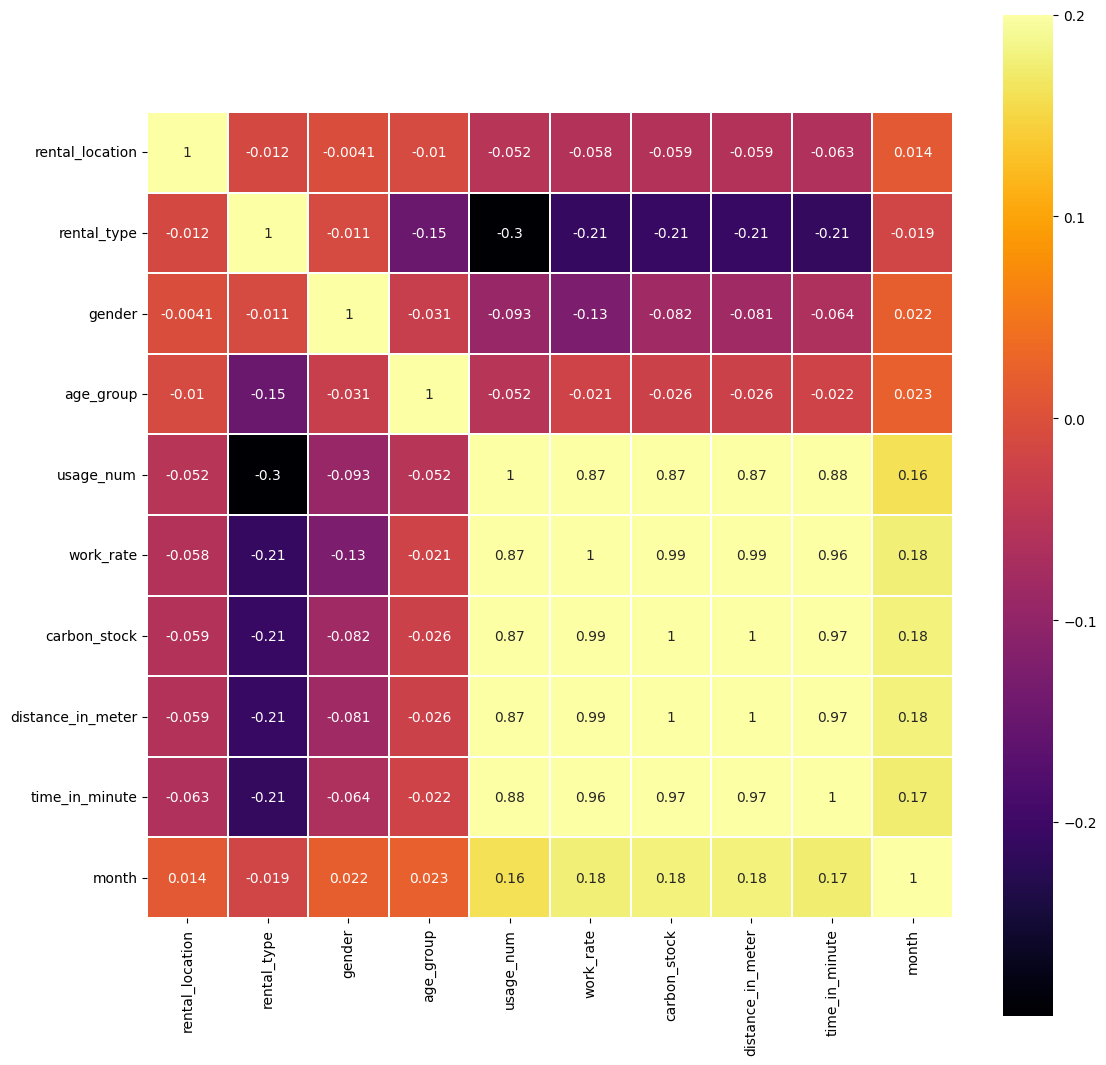

In [ ]:
corr_colormap=plt.cm.inferno
plt.figure(figsize=(13, 13))

sns.heatmap(final_bike.corr(), linewidths = 0.1, vmax = 0.2,
           square = True, cmap = corr_colormap, linecolor = "white", annot = True)
plt.show()

In [ ]:
final_bike.corr(method='pearson')

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month
rental_location,1.000000,-0.011884,-0.004053,-0.010114,-0.051905,-0.057885,-0.058675,-0.058660,-0.062595,0.013992
rental_type,-0.011884,1.000000,-0.010588,-0.147558,-0.295940,-0.210535,-0.208279,-0.208170,-0.212492,-0.018549
gender,-0.004053,-0.010588,1.000000,-0.030916,-0.093198,-0.126471,-0.081503,-0.081400,-0.063547,0.021731
age_group,-0.010114,-0.147558,-0.030916,1.000000,-0.051971,-0.021275,-0.026121,-0.026190,-0.021804,0.023373
usage_num,-0.051905,-0.295940,-0.093198,-0.051971,1.000000,0.868012,0.868430,0.868567,0.884601,0.160010
work_rate,-0.057885,-0.210535,-0.126471,-0.021275,0.868012,1.000000,0.992912,0.992874,0.958221,0.175920
carbon_stock,-0.058675,-0.208279,-0.081503,-0.026121,0.868430,0.992912,1.000000,0.999980,0.970802,0.179344
distance_in_meter,-0.058660,-0.208170,-0.081400,-0.026190,0.868567,0.992874,0.999980,1.000000,0.970843,0.179829
time_in_minute,-0.062595,-0.212492,-0.063547,-0.021804,0.884601,0.958221,0.970802,0.970843,1.000000,0.174052
month,0.013992,-0.018549,0.021731,0.023373,0.160010,0.175920,0.179344,0.179829,0.174052,1.000000


# DNN 분류

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [ ]:
num = ['usage_num', 'work_rate', 'carbon_stock', 'distance_in_meter', 'time_in_minute']
cg = ['rental_type', 'gender', 'age_group', 'month']

bike_input = final_bike[num+cg]
bike_target = np.log1p(final_bike['rental_location'])

X_train, X_test, Y_train, Y_test = train_test_split(bike_input, bike_target, test_size = 0.3, random_state = 42)

ct= ColumnTransformer([('scaling', StandardScaler(), num), ('onehot', OneHotEncoder(sparse = False), cg)])
ct.fit(X_train)
X_train=ct.transform(X_train)
X_test=ct.transform(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.metrics import Accuracy

np.random.seed(0)
tf.random.set_seed(0)

model = keras.models.Sequential()
model.add(keras.layers.Dense(64, input_dim=24, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=64, verbose=2)

Epoch 1/100
3651/3651 - 15s - loss: -4.4423e+06 - accuracy: 0.0000e+00 - val_loss: -1.5902e+07 - val_accuracy: 0.0000e+00 - 15s/epoch - 4ms/step
Epoch 2/100
3651/3651 - 8s - loss: -4.7115e+07 - accuracy: 0.0000e+00 - val_loss: -8.9778e+07 - val_accuracy: 0.0000e+00 - 8s/epoch - 2ms/step
Epoch 3/100
3651/3651 - 8s - loss: -1.6069e+08 - accuracy: 0.0000e+00 - val_loss: -2.4621e+08 - val_accuracy: 0.0000e+00 - 8s/epoch - 2ms/step
Epoch 4/100
3651/3651 - 8s - loss: -3.6920e+08 - accuracy: 0.0000e+00 - val_loss: -5.0928e+08 - val_accuracy: 0.0000e+00 - 8s/epoch - 2ms/step
Epoch 5/100
3651/3651 - 8s - loss: -6.9673e+08 - accuracy: 0.0000e+00 - val_loss: -9.0252e+08 - val_accuracy: 0.0000e+00 - 8s/epoch - 2ms/step
Epoch 6/100
3651/3651 - 9s - loss: -1.1668e+09 - accuracy: 0.0000e+00 - val_loss: -1.4496e+09 - val_accuracy: 0.0000e+00 - 9s/epoch - 2ms/step
Epoch 7/100
3651/3651 - 8s - loss: -1.8029e+09 - accuracy: 0.0000e+00 - val_loss: -2.1737e+09 - val_accuracy: 0.0000e+00 - 8s/epoch - 2ms/st

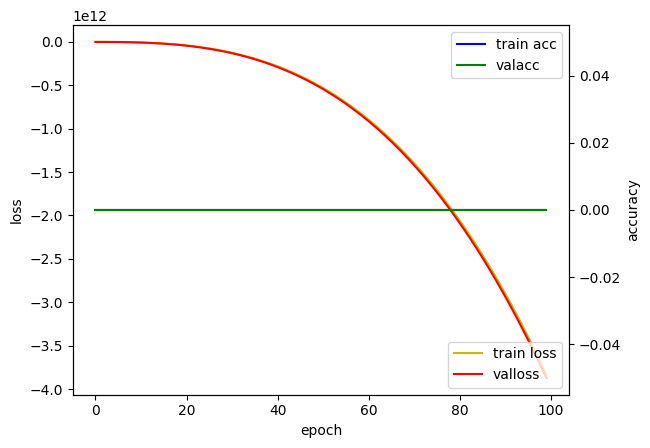

In [ ]:
#1. 모듈 및 함수 불러오기
import matplotlib.pyplot as plt

#2. Figure와 Axes 객체 생성
fig, loss_ax= plt.subplots()
acc_ax= loss_ax.twinx()

#3. 오차 (loss) 그래프 그리기
loss_ax.plot(history.history['loss'], 'y', label='train loss')
loss_ax.plot(history.history['val_loss'], 'r', label='valloss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='lower right')

#4. 정확도 (accuracy) 그래프 그리기
acc_ax.plot(history.history['accuracy'], 'b', label='train acc')
acc_ax.plot(history.history['val_accuracy'], 'g', label='valacc')
acc_ax.set_ylabel('accuracy')
acc_ax.legend(loc='upper right')
plt.show()

In [ ]:
model.fit(X_train, Y_train, epochs=80, batch_size=64, verbose=2)
train_score= model.evaluate(X_train, Y_train, verbose=2)
test_score= model.evaluate(X_test, Y_test, verbose=2)
print(train_score)
print(test_score)

Epoch 1/80
4564/4564 - 15s - loss: -3.9567e+12 - accuracy: 0.0000e+00 - 15s/epoch - 3ms/step
Epoch 2/80
4564/4564 - 7s - loss: -4.1026e+12 - accuracy: 0.0000e+00 - 7s/epoch - 2ms/step
Epoch 3/80
4564/4564 - 10s - loss: -4.2522e+12 - accuracy: 0.0000e+00 - 10s/epoch - 2ms/step
Epoch 4/80
4564/4564 - 7s - loss: -4.4053e+12 - accuracy: 0.0000e+00 - 7s/epoch - 2ms/step
Epoch 5/80
4564/4564 - 10s - loss: -4.5619e+12 - accuracy: 0.0000e+00 - 10s/epoch - 2ms/step
Epoch 6/80
4564/4564 - 7s - loss: -4.7223e+12 - accuracy: 0.0000e+00 - 7s/epoch - 2ms/step
Epoch 7/80
4564/4564 - 10s - loss: -4.8863e+12 - accuracy: 0.0000e+00 - 10s/epoch - 2ms/step
Epoch 8/80
4564/4564 - 7s - loss: -5.0542e+12 - accuracy: 0.0000e+00 - 7s/epoch - 2ms/step
Epoch 9/80
4564/4564 - 11s - loss: -5.2258e+12 - accuracy: 0.0000e+00 - 11s/epoch - 2ms/step
Epoch 10/80
4564/4564 - 10s - loss: -5.4013e+12 - accuracy: 0.0000e+00 - 10s/epoch - 2ms/step
Epoch 11/80
4564/4564 - 9s - loss: -5.5805e+12 - accuracy: 0.0000e+00 - 9s/ep

# Regression

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
num = ['usage_num', 'work_rate', 'carbon_stock', 'distance_in_meter', 'time_in_minute']
cg = ['rental_type', 'gender', 'age_group', 'month']

bike_input = final_bike[num+cg]
bike_target = np.log1p(final_bike['rental_location'])

train_input, test_input, train_target, test_target  = train_test_split(bike_input, bike_target, test_size = 0.2, random_state = 42)

ct = ColumnTransformer([('scaling', StandardScaler(), num), ('onehot', OneHotEncoder(sparse = False), cg)])
ct.fit(train_input)
train_input = ct.transform(train_input)
test_input = ct.transform(test_input)

print(train_input.shape, test_input.shape)
print(train_input)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


(333777, 24) (83445, 24)
[[-0.36953609 -0.40639254 -0.41206827 ...  1.          0.
   0.        ]
 [ 0.09699796  0.24929648  0.34092917 ...  0.          0.
   1.        ]
 [-0.48993198 -0.45212662 -0.45531066 ...  0.          0.
   1.        ]
 ...
 [-0.48993198 -0.48322206 -0.48695733 ...  0.          0.
   0.        ]
 [ 2.44471769  1.77411955  2.10927732 ...  0.          0.
   0.        ]
 [-0.20399175 -0.38212197 -0.36955061 ...  0.          0.
   0.        ]]


In [ ]:
lr = LinearRegression().fit(train_input, train_target)
target_pred = lr.predict(test_input)

print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.010809969390898844
0.009748952482005357


In [ ]:
rmse = sqrt(mean_squared_error(test_target, target_pred))
print('RMSE: {:.3f}'.format(rmse))
print('절편:', np.round(lr.intercept_, 3))
print('가중치:', np.round(lr.coef_, 3))

max(np.round(lr.coef_, 3))

RMSE: 0.918
절편: 7.323
가중치: [ 0.012 -0.113 -0.364  0.523 -0.155  0.088  0.019 -0.107  0.019 -0.019
 -0.005 -0.006  0.073  0.064  0.038  0.012 -0.044 -0.132 -0.051 -0.026
  0.001  0.018  0.026  0.032]


0.523

In [ ]:
num = ['usage_num', 'work_rate', 'carbon_stock', 'distance_in_meter', 'time_in_minute']
cg = ['rental_type', 'gender', 'age_group', 'month']

ss = StandardScaler()
ss.fit_transform(final_bike[num])

bike_input = final_bike[num+cg]
bike_target = np.log1p(final_bike['rental_location'])

train_input, test_input, train_target, test_target  = train_test_split(bike_input, bike_target, test_size = 0.2, random_state = 42)

print(train_input.shape, test_input.shape)

(333777, 9) (83445, 9)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
ridge=Ridge()
ridge.fit(train_input,train_target)
print(ridge.score(train_input,train_target))
print(ridge.score(test_input,test_target))

0.008575332231959387
0.0073820851736703386


In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
elasticnet = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elasticnet.fit(train_input,train_target)
print(elasticnet.score(train_input,train_target))
print(elasticnet.score(test_input,test_target))

0.0068154806592186645
0.0059524105890172985


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures()
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [ ]:
lasso = Lasso()
lasso.fit(train_poly, train_target)
print(lasso.score(train_poly, train_target))
print(lasso.score(test_poly, test_target))

0.009651225086879656
0.007829722810538842


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.410e+05, tolerance: 2.845e+01
  model = cd_fast.enet_coordinate_descent(


#LR w/ MinMaxScaler, RandomForestClassifier

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(train_input)
train_input_mm = minmax_scaler.transform(train_input)
test_input_mm = minmax_scaler.transform(test_input)

lr = LinearRegression().fit(train_input_mm, train_target)
target_pred = lr.predict(test_input_mm)

print(lr.score(train_input_mm, train_target))
print(lr.score(test_input_mm, test_target))

0.00032188017931022994
-0.0005634081308392158


In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
num = ['usage_num', 'work_rate', 'carbon_stock', 'distance_in_meter', 'time_in_minute']
cg = ['rental_type', 'gender', 'age_group', 'month']

ss = StandardScaler()
ss.fit_transform(final_bike[num])

bike_input = final_bike[num+cg]
bike_target = final_bike['rental_location']

train_input, test_input, train_target, test_target  = train_test_split(bike_input, bike_target, test_size = 0.2, random_state = 42)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_target)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_target)
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(train_input, y_train_encoded)
predictions = rf.predict(test_input)
scores = cross_validate(rf, train_input, y_train_encoded, return_train_score=True, n_jobs=2)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))
print(predictions)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Train Score: 0.8538930005694073
Test Score: -0.06752442962940922


# Solution- 지역구 추가



In [ ]:
rental_loc = pd.read_csv('/공공자전거 대여소 정보.csv')
rental_loc

,대여소\n번호,보관소(대여소)명,소재지(위치),Unnamed: 3,Unnamed: 4,Unnamed: 5,설치\n시기,설치형태,Unnamed: 8,운영\n방식
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCD,QR,NaN
1,NaN,NaN,자치구,상세주소,위도,경도,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,거치\n대수,거치\n대수,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,301.0,경복궁역 7번출구 앞,종로구,서울특별시 종로구 사직로 지하130 경복궁역 7번출구 앞,37.57579422,126.9714508,2015-10-07,20,20,QR
...,...,...,...,...,...,...,...,...,...,...
2748,3699.0,상일파출소 옆,강동구,강동구 상일동 520-1,37.55655289,127.1658783,2022-06-21,NaN,15,QR
2749,3700.0,강변그대가리버뷰 입구 맞은편,강동구,강동구 천호동 250-7,37.54816437,127.1225739,2022-07-08,NaN,8,QR
2750,3701.0,방아삼거리,강동구,강동구 둔촌동 118-2,37.5232811,127.1461334,2022-10-12,NaN,8,QR
2751,4951.0,강동농협 버스정류소 앞(광채빌라),강동구,강동구 암사동 488-21,37.547966,127.1351624,2022-09-29,NaN,5,QR


In [ ]:
rentals = rental_loc.dropna(subset=['대여소\n번호'])
rentals

,대여소\n번호,보관소(대여소)명,소재지(위치),Unnamed: 3,Unnamed: 4,Unnamed: 5,설치\n시기,설치형태,Unnamed: 8,운영\n방식
4,301.0,경복궁역 7번출구 앞,종로구,서울특별시 종로구 사직로 지하130 경복궁역 7번출구 앞,37.57579422,126.9714508,2015-10-07,20,20,QR
5,302.0,경복궁역 4번출구 뒤,종로구,서울특별시 종로구 사직로 지하130 경복궁역 4번출구 뒤,37.57594681,126.9740601,2015-10-07,12,12,QR
6,303.0,광화문역 1번출구 앞,종로구,서울특별시 종로구 세종대로 지하189 세종로공원,37.57176971,126.9746628,2015-10-07,8,8,QR
7,305.0,종로구청 옆,종로구,서울특별시 종로구 세종로 84-1,37.57255936,126.9783325,2015-01-07,16,16,QR
8,307.0,서울역사박물관 앞,종로구,서울특별시 종로구 새문안로 55 서울역사박물관 앞,37.56999969,126.9710999,2015-10-07,11,11,QR
...,...,...,...,...,...,...,...,...,...,...
2748,3699.0,상일파출소 옆,강동구,강동구 상일동 520-1,37.55655289,127.1658783,2022-06-21,NaN,15,QR
2749,3700.0,강변그대가리버뷰 입구 맞은편,강동구,강동구 천호동 250-7,37.54816437,127.1225739,2022-07-08,NaN,8,QR
2750,3701.0,방아삼거리,강동구,강동구 둔촌동 118-2,37.5232811,127.1461334,2022-10-12,NaN,8,QR
2751,4951.0,강동농협 버스정류소 앞(광채빌라),강동구,강동구 암사동 488-21,37.547966,127.1351624,2022-09-29,NaN,5,QR


In [ ]:
final_bike['rental_location'] = final_bike['rental_location'].astype(str)
rentals['대여소\n번호'] = rentals['대여소\n번호'].astype(str)
after = pd.merge(final_bike, rentals[['대여소\n번호', '소재지(위치)']], left_on='rental_location', right_on='소재지(위치)', how='inner').shape[0]

<ipython-input-109-5907b5e078e5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rentals['대여소\n번호'] = rentals['대여소\n번호'].astype(str)


In [ ]:
my_rest_api_key = '3dae270fd48d4b32cc9cedc9520e763d'
import requests

url = "https://dapi.kakao.com/v2/local/search/keyword.json"
headers = {"Authorization": "KakaoAK " + my_rest_api_key}
params = {"query": "영등포구청역 1번출구"}

In [ ]:
res = requests.get(url=url, params=params, headers=headers)

import pprint as pp
pp.pprint(res.json())

{'documents': [{'address_name': '서울 영등포구 당산동3가 270-1',
                'category_group_code': '',
                'category_group_name': '',
                'category_name': '교통,수송 > 지하철,전철 > 지하철출구',
                'distance': '',
                'id': '10642080',
                'phone': '',
                'place_name': '영등포구청역 2호선 1번출구',
                'place_url': 'http://place.map.kakao.com/10642080',
                'road_address_name': '',
                'x': '126.896285209314',
                'y': '37.5247489851369'}],
 'meta': {'is_end': True,
          'pageable_count': 1,
          'same_name': {'keyword': '영등포구청역 1번출구',
                        'region': [],
                        'selected_region': ''},
          'total_count': 1}}


In [ ]:
def get_region_from_rental_number(rental_names, default_data=False, verbose=True, process_unit=300):
    total = len(rental_names)
    print("total_size :", total)
    d = {}

    if default_data:
        try:
            for i, row in final_bike.iterrows():
                d[row['rental_location']] = row['구명']
        except Exception as e:
            print(e)
            print(final_bike)

    fail, success = 0, 0
    fail_list = set()
    for i, rental_name in enumerate(rental_names, 1):

        if verbose and i % process_unit == 0:
            print("%d / %d (%d%%) processed.." %(i, total, float(i)/total*100))
        if rental_name in d:
            continue

        params = {"query": "서울 " + rental_name}
        res = requests.get(url=url, params=params, headers=headers)
        result = res.json()['documents']

        if result:
            region = result[0]['address_name'].split()[1]
            d[rental_name] = region
            success += 1
        else:
            if len(rental_name.split()) >= 2:
                params = {"query": "서울 " + "".join(rental_name.split()[:-1])}
                res = requests.get(url=url, params=params, headers=headers)
                result = res.json()['documents']

                if result:
                    region = result[0]['address_name'].split()[1]
                    d[rental_name] = region
                    success += 1
                    continue

            fail_list.add(rental_name)
            fail += 1
    print("sucess: %d(%.1f%%)" %(success, float(success)/(fail+success)*100))
    print("fail: %d(%.1f%%)" %(fail, float(fail)/(fail+success)*100))

    return d, fail_list

In [ ]:
rental_names = set(final_bike['rental_location'].dropna())

In [ ]:
region, fail_list = get_region_from_rental_number(rental_names, default_data=True)

total_size : 2739
-------------------
'구명'
       rental_location  rental_type  gender  age_group  usage_num  work_rate  \
0                  102            2       0          1          4     463.12   
1                  102            1       1          2         31    1618.65   
2                  102            1       1          3         18     805.07   
3                  102            1       1          4          6     447.38   
4                  102            1       1          5          1     204.04   
...                ...          ...     ...        ...        ...        ...   
417217            6054            0       0          5         81    6786.58   
417218            6054            0       0          6         38    2495.04   
417219            6054            0       0          7          1      27.52   
417220            6054            0       0          1         21     890.06   
417221            6054            0       0          0         19     554.31 

In [ ]:
i = 0
region_temp = {}
for k, v in region.items():
    region_temp[k] = v
    i += 1
    if i > 10:
        break
pp.pprint(region_temp)

{'1004': '마포구',
 '117': '영등포구',
 '134': '종로구',
 '1953': '영등포구',
 '223': '강남구',
 '279': '노원구',
 '320': '강동구',
 '356': '서초구',
 '402': '송파구',
 '406': '양천구',
 '502': '강남구'}


In [ ]:
for rental_location, region in region.items():
    final_bike.loc[final_bike['rental_location'] == rental_location, '구명'] = region

In [ ]:
final_bike.dropna(axis=0)

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month,대여소 번호,구명
0,102,2,0,1,4,463.12,4.61,19892.32,116,1,102,성동구
1,102,1,1,2,31,1618.65,16.61,71598.25,797,1,102,성동구
2,102,1,1,3,18,805.07,8.23,35460.54,451,1,102,성동구
3,102,1,1,4,6,447.38,4.32,18611.52,168,1,102,성동구
4,102,1,1,5,1,204.04,1.71,7360.91,37,1,102,성동구
...,...,...,...,...,...,...,...,...,...,...,...,...
416943,5858,0,0,5,221,16207.63,136.35,592871.68,4451,6,5858,종로구
416944,5858,0,0,6,92,11124.26,95.34,410756.15,2579,6,5858,종로구
416945,5858,0,0,7,6,236.37,2.19,9445.22,126,6,5858,종로구
416946,5858,0,0,1,68,6788.21,55.79,240459.11,1466,6,5858,종로구


In [ ]:
fixed_bike = final_bike.drop('대여소 번호', axis=1)

In [ ]:
fixed_bike['구명'].unique()

array([1, 2, 4, 3, nan, 0], dtype=object)

In [ ]:
fixed_bike = fixed_bike.dropna(subset=['구명'])
fixed_bike = fixed_bike.reset_index(drop=True)
print(fixed_bike['구명'].unique())

['성동구' '종로구' '서대문구' '마포구' '서초구' '강남구' '용산구' '영등포구' '중구' '은평구' '금천구' '성북구'
 '송파구' '강동구' '광진구' '도봉구' '중랑구' '노원구' '동작구' '관악구' '구로구' '강서구' '양천구' '강북구'
 '동대문구' '과천시' '남구']


강북, 강남, 강동, 강북, 경기로 범주화

In [ ]:
fixed_bike.loc[fixed_bike['구명'].isin(['과천시', '남구']), '구명'] = 0
fixed_bike.loc[fixed_bike['구명'].isin(['성동구', '종로구', '중구', '송파구', '강동구', '광진구', '동대문구']), '구명'] = 1
fixed_bike.loc[fixed_bike['구명'].isin(['서대문구', '마포구', '용산구', '영등포구', '구로구', '강서구', '양천구']), '구명'] = 2
fixed_bike.loc[fixed_bike['구명'].isin(['은평구', '성북구', '도봉구', '중랑구', '노원구', '강북구']), '구명'] = 3
fixed_bike.loc[fixed_bike['구명'].isin(['서초구', '강남구', '금천구', '동작구', '관악구']), '구명'] = 4
fixed_bike['구명'].value_counts()
fixed_bike.rename(columns={'구명': 'province'}, inplace=True)

In [ ]:
fixed_bike.dropna(axis=0)

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month,구명
0,102,2,0,1,4,463.12,4.61,19892.32,116,1,1
1,102,1,1,2,31,1618.65,16.61,71598.25,797,1,1
2,102,1,1,3,18,805.07,8.23,35460.54,451,1,1
3,102,1,1,4,6,447.38,4.32,18611.52,168,1,1
4,102,1,1,5,1,204.04,1.71,7360.91,37,1,1
...,...,...,...,...,...,...,...,...,...,...,...
416943,5858,0,0,5,221,16207.63,136.35,592871.68,4451,6,1
416944,5858,0,0,6,92,11124.26,95.34,410756.15,2579,6,1
416945,5858,0,0,7,6,236.37,2.19,9445.22,126,6,1
416946,5858,0,0,1,68,6788.21,55.79,240459.11,1466,6,1


In [ ]:
fixed_bike.rename(columns={'구명': 'province'}, inplace=True)

In [ ]:
fixed_bike = fixed_bike.dropna(subset=['province'])
fixed_bike['province'] = fixed_bike['province'].astype(int)

In [ ]:
fixed_bike = fixed_bike.reset_index(drop=True)

In [ ]:
fixed_bike

,rental_location,rental_type,gender,age_group,usage_num,work_rate,carbon_stock,distance_in_meter,time_in_minute,month,province
0,102,2,0,1,4,463.12,4.61,19892.32,116,1,1
1,102,1,1,2,31,1618.65,16.61,71598.25,797,1,1
2,102,1,1,3,18,805.07,8.23,35460.54,451,1,1
3,102,1,1,4,6,447.38,4.32,18611.52,168,1,1
4,102,1,1,5,1,204.04,1.71,7360.91,37,1,1
...,...,...,...,...,...,...,...,...,...,...,...
131649,5858,0,0,5,221,16207.63,136.35,592871.68,4451,6,1
131650,5858,0,0,6,92,11124.26,95.34,410756.15,2579,6,1
131651,5858,0,0,7,6,236.37,2.19,9445.22,126,6,1
131652,5858,0,0,1,68,6788.21,55.79,240459.11,1466,6,1


# 새로운 데이터를 이용한 모델 성능

1. logistic regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
num = ['usage_num', 'work_rate', 'carbon_stock', 'distance_in_meter', 'time_in_minute']
cg = ['rental_type', 'gender', 'age_group', 'month']

ss = StandardScaler()
ss.fit_transform(fixed_bike[num])

bike_input = fixed_bike[num+cg]
bike_target = fixed_bike['province']

train_input, test_input, train_target, test_target  = train_test_split(bike_input, bike_target, test_size = 0.2, random_state = 42)
print(train_input.shape, test_input.shape)

(105323, 9) (26331, 9)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(random_state=0, C=0.1,solver='newton-cg', multi_class='multinomial')

model.fit(train_input, train_target)
Y_pred = model.predict(test_input)

print(model.score(train_input, train_target))
print(model.score(test_input, test_target))
print("Test Accuracy: %f"%accuracy_score(test_target, Y_pred))

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:466: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
/usr/local/lib/python3.10/dist-packages/scipy/optimize/_linesearch.py:314: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)


0.3126857381578573
0.31818009190687785
Test Accuracy: 0.318180


/usr/local/lib/python3.10/dist-packages/sklearn/utils/optimize.py:210: ConvergenceWarning: newton-cg failed to converge. Increase the number of iterations.
  warnings.warn(


2. knn

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

mylist = list(range(1,50))
k_list = [x for x in mylist if x %2 !=0]
parameter_grid = {'n_neighbors':k_list}

grid_search = GridSearchCV(KNeighborsClassifier(), parameter_grid, cv = 10)
grid_search.fit(train_input, train_target)
print('최적의 인자 :', grid_search.best_params_)

최적의 인자 : {'n_neighbors': 45}


In [ ]:
from imblearn.over_sampling import SMOTE
train_over_input, train_over_target = SMOTE(random_state=42).fit_resample(train_input, train_target)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model= KNeighborsClassifier(n_neighbors=45, metric='euclidean')

model.fit(train_input, train_target)
Y_pred = model.predict(test_input)

print(model.score(train_over_input, train_over_target))
print(model.score(test_input, test_target))
print("Test Accuracy: %f"%accuracy_score(test_target, Y_pred))

0.2492621673642724
0.2928867114807641
Test Accuracy: 0.292887


3. SGDClassifier

In [ ]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log', max_iter=10, random_state=42)
sc.fit(train_input, train_target)
Y_pred = sc.predict(test_input)

print(sc.score(train_input, train_target))
print(sc.score(test_input, test_target))
print("Test Accuracy: %f"%accuracy_score(test_target, Y_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


0.2661242083875317
0.25779499449318294
Test Accuracy: 0.257795


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
sc.partial_fit(train_input, train_target)
print(sc.score(train_input, train_target))
print(sc.score(test_input, test_target))

0.00301928353730904
0.0032281341384679655


In [ ]:
sc = SGDClassifier(loss='log', max_iter=100, tol=None, random_state=42)
sc.fit(train_input, train_target)
Y_pred = sc.predict(test_input)

print(sc.score(train_input, train_target))
print(sc.score(test_input, test_target))
print("Test Accuracy: %f"%accuracy_score(test_target, Y_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


0.26608622997825737
0.25760510424974364
Test Accuracy: 0.257605


In [ ]:
scores = cross_validate(sc, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.24988125725546168 0.25154076385744345


In [ ]:
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_input, train_target)
Y_pred = sc.predict(test_input)

print(sc.score(train_input, train_target))
print(sc.score(test_input, test_target))
print("Test Accuracy: %f"%accuracy_score(test_target, Y_pred))

0.26609572458057595
0.2576430822984315
Test Accuracy: 0.257643


4. RandomForestClassifier

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.9998718228236212 0.2932597838657749


In [ ]:
from sklearn.model_selection import GridSearchCV

params = { 'n_estimators' : [10, 100, 200, 150],
           'max_depth' : [6, 8, 10, 12, 50, 100]}

rf_clf = RandomForestClassifier(random_state = 42, n_jobs = -1)
grid_cv = GridSearchCV(rf_clf, param_grid = params, cv = 3, n_jobs = -1)
grid_cv.fit(train_input, train_target)

print('최적 하이퍼 파라미터: ', grid_cv.best_params_)
print('최고 예측 정확도: {:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:  {'max_depth': 8, 'n_estimators': 200}
최고 예측 정확도: 0.3151


In [ ]:
rf = RandomForestClassifier(max_depth = 8, n_estimators = 200, n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.3386890773902448 0.31591390347764314


5. GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.3336854231457315 0.3129516059429024


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators' : [10, 100, 200, 300],
           'learning_rate' : [0.05, 0.1, 0.2]}

rf_clf = GradientBoostingClassifier(random_state = 42)
grid_cv = GridSearchCV(rf_clf, param_grid = params, cv = 3, n_jobs = -1)
grid_cv.fit(train_input, train_target)

print('최적 하이퍼 파라미터: ', grid_cv.best_params_)
print('최고 예측 정확도: {:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:  {'learning_rate': 0.2, 'n_estimators': 10}
최고 예측 정확도: 0.3145


In [ ]:
gb = GradientBoostingClassifier(n_estimators=10, learning_rate=0.2, random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.31879076758906894 0.3138061039253377


6. XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.45558425480882764 0.30793843662423714


In [ ]:
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.utils.fixes import loguniform
from sklearn.metrics import accuracy_score


xgv_param_grid = { 'n_estimators': [400, 600, 1000],
                  'learning_rate': [0.01 ,0.1, 0.2],
                  'max_depth': [4,6],
                  'min_child_weight': [1,2,3]}

xgv_grid = GridSearchCV(xgb, param_grid =xgv_param_grid, scoring = 'accuracy', verbose=3).fit(train_input,train_target,verbose=1)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV 1/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400;, score=0.318 total time=  19.5s
[CV 2/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400;, score=0.312 total time=  21.4s
[CV 3/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400;, score=0.315 total time=  19.2s
[CV 4/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400;, score=0.317 total time=  17.8s
[CV 5/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=400;, score=0.317 total time=  17.6s
[CV 1/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=600;, score=0.317 total time=  25.2s
[CV 2/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=600;, score=0.312 total time=  28.2s
[CV 3/5] END learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=600;, score=0.315 total time=  29.8s
[CV 4/5] E

In [ ]:
xgv_pred = xgv_grid.predict(test_input)
print("Test Accuracy: %f"% accuracy_score(test_target,xgv_pred))

Test Accuracy: 0.320003


In [ ]:
 xgv_grid.best_params_

{'learning_rate': 0.01,
 'max_depth': 4,
 'min_child_weight': 1,
 'n_estimators': 400}

In [ ]:
xgb = XGBClassifier(tree_method='hist', learning_rate = 0.01, max_depth=4, min_child_weight = 1, n_estimators= 400, random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)

print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.32378493141184234 0.31579048906279905


In [ ]:
xgb = XGBClassifier(tree_method='hist', learning_rate = 0.01, max_depth=4, min_child_weight = 1, n_estimators= 400, random_state=42)
xgb.fit(train_input, train_target)

print(xgb.score(train_input, train_target))
print(xgb.score(test_input, test_target))

0.32101250439125356
0.32000303824389503


# 가장 성능이 좋은 xgboost classifier을 이용한 예측





In [ ]:
for i in range(10):
  print("True:", test_target.iloc[i], "Predict:", xgv_pred[i])

True: 4 Predict: 4
True: 4 Predict: 4
True: 3 Predict: 4
True: 4 Predict: 4
True: 3 Predict: 4
True: 4 Predict: 4
True: 2 Predict: 4
True: 2 Predict: 4
True: 1 Predict: 4
True: 2 Predict: 4


In [ ]:
print("True:", test_target.iloc[12453], "Predict:", xgv_pred[1951])

True: 4 Predict: 4
